In [10]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (2).json


{'kaggle (2).json': b'{"username":"fatoumatabamba","key":"f516d813298ae471b8027151d7d0ebaf"}'}

In [20]:
!rm -f ~/.kaggle/kaggle.json
!mkdir -p ~/.kaggle
!cp "kaggle (2).json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json


In [13]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!pip install -q kaggle

In [22]:
!kaggle datasets download -d emmarex/plantdisease
!unzip -q plantdisease.zip -d plant_data

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:07<00:00, 96.0MB/s]



In [23]:
import os
print(os.listdir("plant_data"))


['PlantVillage', 'plantvillage']


In [24]:
import os

# on regarde le contenu du dossier avec majuscule (généralement le bon)
base_dir = "plant_data/PlantVillage"
categories = os.listdir(base_dir)
print(f"Nombre de catégories : {len(categories)}")
print(categories)

Nombre de catégories : 15
['Tomato__Tomato_mosaic_virus', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Pepper__bell___healthy', 'Tomato_Late_blight', 'Tomato_Early_blight', 'Potato___healthy', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Pepper__bell___Bacterial_spot', 'Tomato_Leaf_Mold', 'Tomato__Target_Spot', 'Tomato_Bacterial_spot', 'Tomato_Septoria_leaf_spot', 'Potato___Late_blight', 'Potato___Early_blight', 'Tomato_healthy']


In [25]:
for cat in categories[:5]:  # on regarde juste les 5 premières pour l'instant
    path = os.path.join(base_dir, cat)
    n_images = len(os.listdir(path))
    print(f"{cat} : {n_images} images")

Tomato__Tomato_mosaic_virus : 373 images
Tomato__Tomato_YellowLeaf__Curl_Virus : 3209 images
Pepper__bell___healthy : 1478 images
Tomato_Late_blight : 1909 images
Tomato_Early_blight : 1000 images


In [26]:
counts = {}
for cat in categories:
    path = os.path.join(base_dir, cat)
    n_images = len(os.listdir(path))
    counts[cat] = n_images

# trier du plus grand au plus petit pour mieux visualiser
for cat, n in sorted(counts.items(), key=lambda x: x[1], reverse=True):
    print(f"{cat} : {n} images")

print(f"\nTotal : {sum(counts.values())} images")

Tomato__Tomato_YellowLeaf__Curl_Virus : 3209 images
Tomato_Bacterial_spot : 2127 images
Tomato_Late_blight : 1909 images
Tomato_Septoria_leaf_spot : 1771 images
Tomato_Spider_mites_Two_spotted_spider_mite : 1676 images
Tomato_healthy : 1591 images
Pepper__bell___healthy : 1478 images
Tomato__Target_Spot : 1404 images
Tomato_Early_blight : 1000 images
Potato___Late_blight : 1000 images
Potato___Early_blight : 1000 images
Pepper__bell___Bacterial_spot : 997 images
Tomato_Leaf_Mold : 952 images
Tomato__Tomato_mosaic_virus : 373 images
Potato___healthy : 152 images

Total : 20639 images


In [27]:
tomato_categories = [cat for cat in categories if cat.startswith("Tomato")]
print(tomato_categories)
print(f"\n{len(tomato_categories)} catégories tomate")


['Tomato__Tomato_mosaic_virus', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Late_blight', 'Tomato_Early_blight', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Leaf_Mold', 'Tomato__Target_Spot', 'Tomato_Bacterial_spot', 'Tomato_Septoria_leaf_spot', 'Tomato_healthy']

10 catégories tomate


In [28]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import shutil

# on crée un nouveau dossier avec seulement les catégories tomate
tomato_dir = "plant_data/tomato_only"
os.makedirs(tomato_dir, exist_ok=True)

for cat in tomato_categories:
    src = os.path.join(base_dir, cat)
    dst = os.path.join(tomato_dir, cat)
    if not os.path.exists(dst):
        shutil.copytree(src, dst)

print("fait")
print(os.listdir(tomato_dir))

fait
['Tomato__Tomato_mosaic_virus', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Late_blight', 'Tomato_Early_blight', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Leaf_Mold', 'Tomato__Target_Spot', 'Tomato_Bacterial_spot', 'Tomato_Septoria_leaf_spot', 'Tomato_healthy']


In [29]:
img_size = (160, 160)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,        # normalise les pixels entre 0 et 1
    validation_split=0.2   # 20% des images serviront à valider le modèle
)

train_gen = datagen.flow_from_directory(
    tomato_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

val_gen = datagen.flow_from_directory(
    tomato_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

Found 12813 images belonging to 10 classes.
Found 3198 images belonging to 10 classes.


In [30]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# on charge MobileNetV2 déjà entraîné sur ImageNet, sans sa dernière couche
base_model = MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False,
    weights="imagenet"
)

# on gèle ses poids : on ne veut pas ré-entraîner tout le modèle, juste l'adapter
base_model.trainable = False

# on ajoute nos propres couches par-dessus, adaptées à nos 10 classes
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")  # 10 classes de tomate
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [31]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

Epoch 1/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 70s 126ms/step - accuracy: 0.7622 - loss: 0.7101 - val_accuracy: 0.8684 - val_loss: 0.3910
Epoch 2/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.8745 - loss: 0.3686 - val_accuracy: 0.9112 - val_loss: 0.2704
Epoch 3/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.8965 - loss: 0.3007 - val_accuracy: 0.9087 - val_loss: 0.2579
Epoch 4/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.9148 - loss: 0.2459 - val_accuracy: 0.9212 - val_loss: 0.2326
Epoch 5/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - accuracy: 0.9263 - loss: 0.2143 - val_accuracy: 0.9115 - val_loss: 0.2494
Epoch 6/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.9365 - loss: 0.1857 - val_accuracy: 0.9284 - val_loss: 0.2208
Epoch 7/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.9413 - loss: 0.1686 - val_accuracy: 0.9262 - val_loss: 0.2181
Epoch 8/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 22s 54ms/step - accuracy: 0.9486 - loss: 0.1491 -

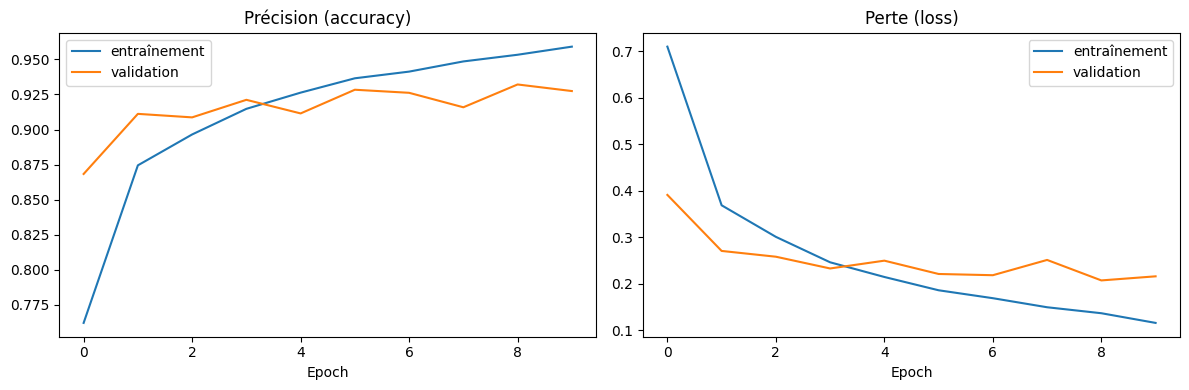

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="entraînement")
plt.plot(history.history["val_accuracy"], label="validation")
plt.title("Précision (accuracy)")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="entraînement")
plt.plot(history.history["val_loss"], label="validation")
plt.title("Perte (loss)")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()


In [33]:
model.save("tomato_disease_model.h5")
print("Modèle sauvegardé")

Modèle sauvegardé


In [34]:
from google.colab import files
uploaded = files.upload()

Saving photosynthese-feuilles.jpg.webp to photosynthese-feuilles.jpg.webp


In [35]:
from tensorflow.keras.preprocessing import image
import numpy as np

# récupère le nom du fichier uploadé
img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(160, 160))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
class_names = list(train_gen.class_indices.keys())
predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

print(f"Prédiction : {predicted_class}")
print(f"Confiance : {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Prédiction : Tomato_Septoria_leaf_spot
Confiance : 74.43%


100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step


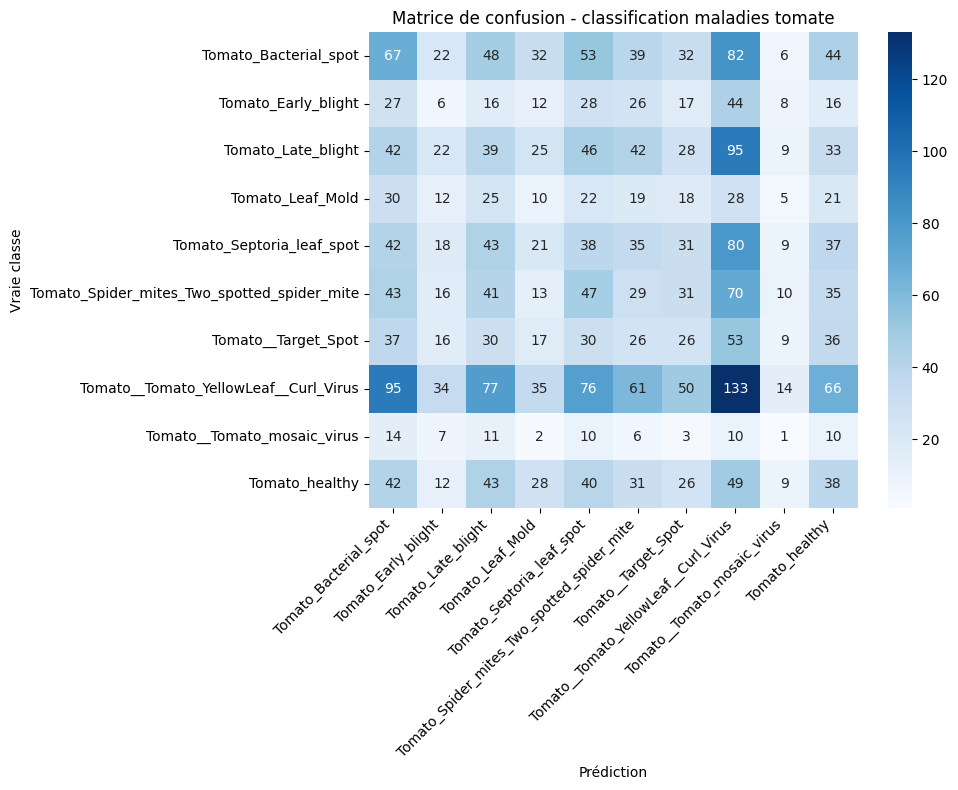

                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot       0.15      0.16      0.16       425
                        Tomato_Early_blight       0.04      0.03      0.03       200
                         Tomato_Late_blight       0.10      0.10      0.10       381
                           Tomato_Leaf_Mold       0.05      0.05      0.05       190
                  Tomato_Septoria_leaf_spot       0.10      0.11      0.10       354
Tomato_Spider_mites_Two_spotted_spider_mite       0.09      0.09      0.09       335
                        Tomato__Target_Spot       0.10      0.09      0.10       280
      Tomato__Tomato_YellowLeaf__Curl_Virus       0.21      0.21      0.21       641
                Tomato__Tomato_mosaic_virus       0.01      0.01      0.01        74
                             Tomato_healthy       0.11      0.12      0.12       318

                                   accuracy                    

In [36]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# on récupère les vraies étiquettes et les prédictions sur tout le jeu de validation
val_gen.reset()
y_true = val_gen.classes
y_pred_probs = model.predict(val_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

class_names = list(val_gen.class_indices.keys())

# matrice de confusion
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Prédiction")
plt.ylabel("Vraie classe")
plt.title("Matrice de confusion - classification maladies tomate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

# rapport détaillé : précision, rappel, f1-score par classe
print(classification_report(y_true, y_pred, target_names=class_names))

Found 3198 images belonging to 10 classes.
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step


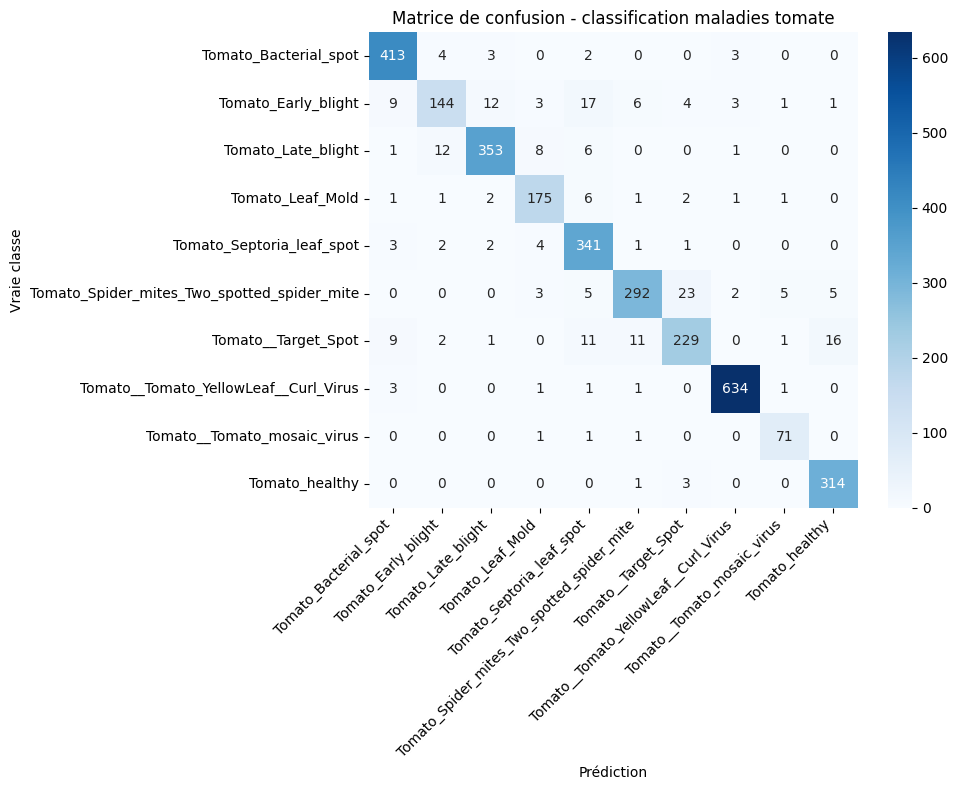

                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot       0.94      0.97      0.96       425
                        Tomato_Early_blight       0.87      0.72      0.79       200
                         Tomato_Late_blight       0.95      0.93      0.94       381
                           Tomato_Leaf_Mold       0.90      0.92      0.91       190
                  Tomato_Septoria_leaf_spot       0.87      0.96      0.92       354
Tomato_Spider_mites_Two_spotted_spider_mite       0.93      0.87      0.90       335
                        Tomato__Target_Spot       0.87      0.82      0.85       280
      Tomato__Tomato_YellowLeaf__Curl_Virus       0.98      0.99      0.99       641
                Tomato__Tomato_mosaic_virus       0.89      0.96      0.92        74
                             Tomato_healthy       0.93      0.99      0.96       318

                                   accuracy                    

In [37]:
# générateur séparé, sans mélange, uniquement pour évaluer correctement
eval_gen = datagen.flow_from_directory(
    tomato_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation",
    shuffle=False   # <-- la correction clé
)

y_true = eval_gen.classes
y_pred_probs = model.predict(eval_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

class_names = list(eval_gen.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Prédiction")
plt.ylabel("Vraie classe")
plt.title("Matrice de confusion - classification maladies tomate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

In [38]:
model.save("tomato_disease_model.h5")
print("Modèle sauvegardé :", os.path.getsize("tomato_disease_model.h5") / (1024*1024), "MB")

Modèle sauvegardé : 10.860298156738281 MB


In [39]:
from google.colab import files

files.download("tomato_disease_model.h5")
files.download("training_curves.png")
files.download("confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>